<a href="https://colab.research.google.com/github/sjkim-audio/Bass-separator/blob/main/notebooks/transcription/06_Main_pitch_track.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =================================================================
# [Bass Separator] Integrated Setup & Initialization
# =================================================================
from google.colab import drive
import os
import sys

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 프로젝트 최신화 (Git Clone / Pull)
PROJECT_NAME = "Bass-separator"
REPO_URL = "https://github.com/sjkim-audio/Bass-separator.git"
PROJECT_PATH = f"/content/{PROJECT_NAME}"

if not os.path.exists(PROJECT_PATH):
    print(f"📦 Cloning repository... ({PROJECT_NAME})")
    !git clone {REPO_URL}
else:
    print(f"🔄 Updating repository... (Git Pull)")
    !cd {PROJECT_PATH} && git pull

# 3. 작업 경로 설정
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
os.chdir(PROJECT_PATH)
print(f"📂 Working Directory: {os.getcwd()}")

# 4. [src] 모듈을 이용한 환경 구축 및 데이터 로드
try:
    from src.env_setup import init_colab_env
    from src.utils import load_data_from_drive

    # A. 설치 및 환경 설정 (FFmpeg, Demucs, 호환성 해결)
    init_colab_env()

    # B. 데이터셋 로드
    MY_DRIVE_PATH = "/content/drive/MyDrive/Bass_separator/dataset"
    load_data_from_drive(MY_DRIVE_PATH)

except ImportError as e:
    print(f"⚠️ src 모듈 로드 실패: {e}")
    print("   Git Clone이 정상적으로 되었는지 확인해주세요.")

# 5. 자주 쓰는 라이브러리 임포트 (편의용)
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
import soundfile as sf
from IPython.display import Audio, display
import subprocess
import torch
print("📚 Standard Libraries Imported.")

Mounted at /content/drive
📦 Cloning repository... (Bass-separator)
Cloning into 'Bass-separator'...
remote: Enumerating objects: 765, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 765 (delta 170), reused 69 (delta 63), pack-reused 499 (from 1)
Receiving objects: 100% (765/765), 304.44 MiB | 21.65 MiB/s, done.
Resolving deltas: 100% (421/421), done.
Updating files: 100% (40/40), done.
📂 Working Directory: /content/Bass-separator
⚠️ src 모듈 로드 실패: No module named 'shuti'
   Git Clone이 정상적으로 되었는지 확인해주세요.
📚 Standard Libraries Imported.


In [12]:
# 분석할 오디오 파일의 경로를 입력
target_file_path = "/content/drive/MyDrive/Bass_separator/dataset/performance_test_demo(guitar + bass).wav"

# Demucs로 베이스 트랙 분리
print("🚀 Demucs 분리 시작...")

# 파일명 추출 (확장자 제외)
filename = os.path.splitext(os.path.basename(target_file_path))[0]

# Demucs 실행 (htdemucs 모델 사용)
cmd = f'demucs -n htdemucs "{target_file_path}"'
process = subprocess.run(cmd, shell=True, capture_output=True, text=True, check=False)

# 분리된 베이스 파일 경로 자동 탐색
# Demucs 기본 출력 경로: separated/htdemucs/파일명/bass.wav
bass_stem_path = os.path.join('separated', 'htdemucs', filename, 'bass.wav')
print(f"✅ 분리 완료! 베이스 트랙 경로: {bass_stem_path}")

🚀 Demucs 분리 시작...
✅ 분리 완료! 베이스 트랙 경로: separated/htdemucs/performance_test_demo(guitar + bass)/bass.wav


In [ ]:
!pip install torchcrepe

In [6]:
# ==================================================================================
# [Part 1] 핵심 함수 정의
# ==================================================================================
import torchcrepe.decode
import torch
import torchcrepe

def clean_octave_errors(f0_array, valid_threshold=12, window_size=7):
    """
    [Post-Process] 배음(Harmonics)으로 인한 옥타브 오류(±12 Semitones)를 보정
    """
    f0_clean = f0_array.copy()

    # 유효한 구간(0이나 NaN이 아닌 곳)만 처리
    mask = (f0_clean > 0) & (~np.isnan(f0_clean))
    if np.sum(mask) == 0:
        return f0_clean

    # Hz -> MIDI 변환
    midi_notes = np.zeros_like(f0_clean)
    midi_notes[mask] = librosa.hz_to_midi(f0_clean[mask])

    # 이동 중앙값(Rolling Median)으로 전체적인 멜로디 트렌드 파악
    midi_series = pd.Series(midi_notes)
    # NaN이 아닌 값들만 이용해서 트렌드 라인을 그림
    trend = midi_series.where(mask).rolling(window=window_size, center=True, min_periods=1).median().values

    # 트렌드와 급격하게 차이나는(12반음) 구간 보정
    indices = np.where(mask)[0]
    correction_count = 0

    for i in indices:
        if np.isnan(trend[i]): continue

        diff = midi_notes[i] - trend[i]

        # +1 옥타브 오류 (약 +12)
        if 10 <= diff <= 14:
            midi_notes[i] -= 12
            correction_count += 1
        # +2 옥타브 오류 (약 +24)
        elif 22 <= diff <= 26:
            midi_notes[i] -= 24
            correction_count += 1
        # -1 옥타브 오류 (약 -12)
        elif -14 <= diff <= -10:
            midi_notes[i] += 12
            correction_count += 1

    # 보정된 MIDI -> Hz 복구
    f0_clean[mask] = librosa.midi_to_hz(midi_notes[mask])

    # (디버깅용) 얼마나 고쳤는지 출력하고 싶으면 주석 해제
    # print(f"   🔧 Octave Correction: Fixed {correction_count} frames.")

    return f0_clean

def get_f0_crepe_robust(audio, sr, hop_length=160, fmin=40, fmax=500, smooth_kernel=3, chunk_duration=30):
    """
    [Main Pipeline] 노이즈에 강한 베이스 전용 피치 트래커
    (Pre-processing -> CREPE (OOM Safe Chunking) -> Post-processing)
    """
    # 1. [Pre] High-pass Filter (35Hz Cutoff for Rumble noise)
    sos = scipy.signal.butter(4, 35, 'hp', fs=sr, output='sos')
    audio = scipy.signal.sosfilt(sos, audio)

    # 2. [Pre] Audio Normalization
    if np.max(np.abs(audio)) < 1e-6:
        return np.zeros(len(audio) // hop_length)
    audio = librosa.util.normalize(audio)

    # 3. Setup Device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 4. CREPE Inference (OOM 방어를 위한 Chunking 처리)
    chunk_samples = int(chunk_duration * sr)
    # 프레임 밀림 현상 방지를 위해 chunk_samples를 hop_length의 배수로 정렬
    chunk_samples = chunk_samples - (chunk_samples % hop_length)
    total_samples = len(audio)

    f0_list = []
    confidence_list = []

    for start_idx in range(0, total_samples, chunk_samples):
        end_idx = min(start_idx + chunk_samples, total_samples)
        audio_chunk = audio[start_idx:end_idx]

        # 마지막 청크가 1024 샘플 미만일 경우 패딩 처리 (CREPE 내부 에러 방지)
        if len(audio_chunk) < 1024:
            pad_len = 1024 - len(audio_chunk)
            audio_chunk = np.pad(audio_chunk, (0, pad_len), mode='constant')

        audio_tensor = torch.tensor(audio_chunk).float().unsqueeze(0).to(device)

        # GTX 960 환경을 고려하여 batch_size를 256으로 하향 조정
        f0_chunk, conf_chunk = torchcrepe.predict(
            audio_tensor,
            sr,
            hop_length=hop_length,
            fmin=fmin,
            fmax=fmax,
            model='full',
            decoder=torchcrepe.decode.argmax,
            return_periodicity=True,
            device=device,
            batch_size=256
        )

        f0_list.append(f0_chunk.squeeze().cpu().numpy())
        confidence_list.append(conf_chunk.squeeze().cpu().numpy())

        # 즉각적인 VRAM 가비지 컬렉션
        del audio_tensor, f0_chunk, conf_chunk
        if device == 'cuda':
            torch.cuda.empty_cache()

    # 분할된 청크 결과 병합
    f0 = np.concatenate(f0_list)
    confidence = np.concatenate(confidence_list)

    # 패딩으로 인해 늘어난 프레임 길이를 원본 기대 길이로 정확히 절사
    expected_frames = 1 + int(total_samples // hop_length)
    f0 = f0[:expected_frames]
    confidence = confidence[:expected_frames]

    # 5. [Post] Confidence Masking (신뢰도 15% 미만 삭제)
    f0[confidence < 0.15] = np.nan

    # 6. [Post] Median Filter (Spike Removal)
    if smooth_kernel > 1:
        f0_series = pd.Series(f0)
        f0 = f0_series.rolling(window=smooth_kernel, center=True, min_periods=1).median().values

    # 7. [Post] Octave Error Correction
    f0 = clean_octave_errors(f0, window_size=7)

    # 8. [Post] Final Refinement (Quantization & 200Hz Cutoff)
    f0 = post_process_refinement(f0, hop_length, sr)

    return f0


def post_process_refinement(f0, hop_length, sr, min_duration_ms=50):
    """
    [최종 보정] 양자화(Quantization) 및 짧은 노이즈 제거
    """
    f0_clean = f0.copy()

    # 0. High Frequency Cutoff (300Hz 이상 삭제)
    f0_clean[f0_clean > 200] = np.nan

    # ---------------------------------------------------------
    # 1. Quantization (Hz -> MIDI Note 반올림 -> Hz)
    # ---------------------------------------------------------
    # 유효한 구간(NaN이 아닌 곳)만 처리
    valid_mask = ~np.isnan(f0_clean)

    if np.sum(valid_mask) > 0:
        # Hz를 MIDI 번호로 변환 (예: 48.2Hz -> 42.8)
        midi_float = librosa.hz_to_midi(f0_clean[valid_mask])

        # 반올림하여 정수형 MIDI 노트로 만듦 (예: 42.8 -> 43)
        midi_round = np.round(midi_float)

        # 다시 Hz로 변환 (이제 48.2Hz가 아니라 48.99Hz 처럼 딱 떨어지는 음이 됨)
        f0_clean[valid_mask] = librosa.midi_to_hz(midi_round)

    # ---------------------------------------------------------
    # 2. Short Note Removal (짧은 잡음 제거)
    # ---------------------------------------------------------
    # 최소 프레임 수 계산 (예: 50ms / 10ms = 5 frames)
    min_frames = int((min_duration_ms / 1000) * (sr / hop_length))

    # 연속된 구간 길이 측정 로직
    # (간단하게 구현하기 위해 pandas 활용 추천, 없으면 numpy로 구현)
    import pandas as pd

    # MIDI 노트로 변환된 상태에서 그룹핑
    # NaN은 -1로 치환하여 구분
    temp_notes = f0_clean.copy()
    temp_notes[np.isnan(temp_notes)] = -1

    series = pd.Series(temp_notes)

    # 값이 바뀌는 지점마다 그룹 ID 부여
    groups = (series != series.shift()).cumsum()

    # 각 그룹의 길이 계산
    counts = series.groupby(groups).transform('count')

    # "길이가 너무 짧고" AND "무음(-1)이 아닌" 구간을 NaN으로 변경
    mask_short = (counts < min_frames) & (series != -1)
    f0_clean[mask_short] = np.nan

    return f0_clean

In [10]:
# ==================================================================================
# [Part 2] 실행 및 검증
# ==================================================================================

# 1. 설정
TARGET_SR = 16000
HOP_LENGTH = 160 # 10ms
BASS_STEM_PATH = bass_stem_path

if os.path.exists(BASS_STEM_PATH):
    print(f"📂 Processing: {BASS_STEM_PATH}")

    # 2. 오디오 로드
    y, sr = librosa.load(BASS_STEM_PATH, sr=TARGET_SR)

    # 3. 피치 트래킹 실행
    print("🚀 Running Robust Pitch Tracking...")
    f0_result = get_f0_crepe_robust(y, sr, hop_length=HOP_LENGTH)

    # 4. 결과 통계
    valid_mask = ~np.isnan(f0_result)
    valid_notes = f0_result[valid_mask]

    print(f"✅ Analysis Complete!")
    print(f"   - Total Frames: {len(f0_result)}")
    print(f"   - Valid Notes : {len(valid_notes)} ({(len(valid_notes)/len(f0_result))*100:.1f}%)")

    if len(valid_notes) > 0:
        print(f"   - Pitch Range : {np.min(valid_notes):.1f} Hz ~ {np.max(valid_notes):.1f} Hz")

        # 5. 시각화 (결과 확인)
        plt.figure(figsize=(14, 6))
        times = np.linspace(0, len(y) / sr, len(f0_result))

        # 메인 그래프
        plt.scatter(times, f0_result, s=5, c='dodgerblue', alpha=0.6, label='Detected Pitch')

        plt.title(f"Final Bass Line Analysis (Robust CREPE)")
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.ylim(0, 450) # 베이스 음역대
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()

        # 6. (선택사항) 데이터 저장 - 다음 단계를 위해!
        # save_path = "./processed_f0.npy"
        # np.save(save_path, f0_result)
        # print(f"💾 Feature saved to: {save_path}")

    else:
        print("⚠️ 유효한 피치가 감지되지 않았습니다.")
else:
    print("❌ 파일 경로를 확인해주세요.")

❌ 파일 경로를 확인해주세요.


🔧 Refiring Pitch Data...


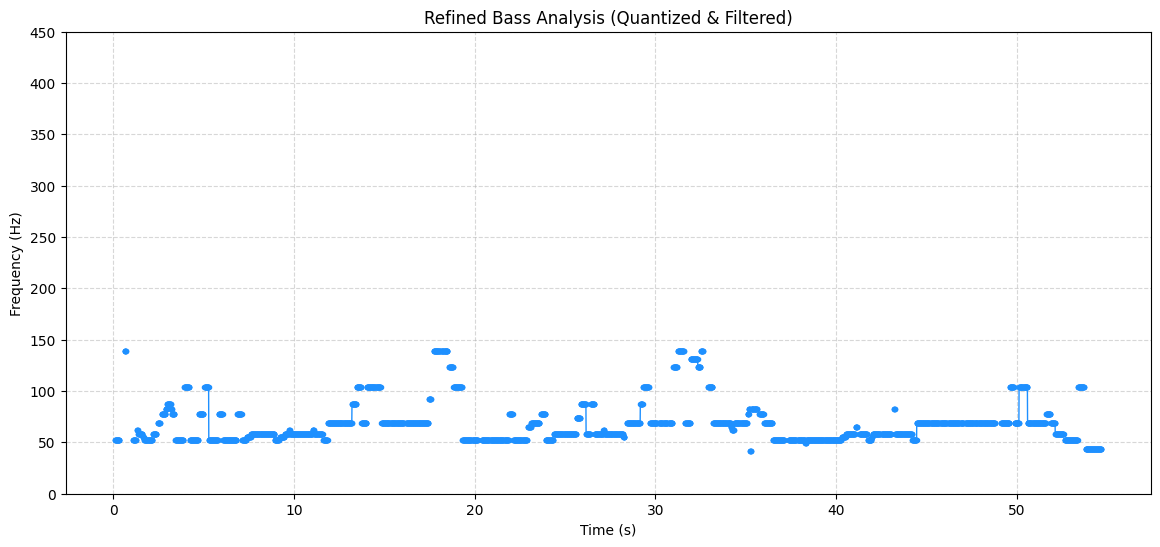

In [ ]:
print("🔧 Refiring Pitch Data...")
f0_final = post_process_refinement(f0_result, hop_length=160, sr=16000)

# 2. 시각화 비교 (Scatter 대신 Plot 권장)

plt.figure(figsize=(14, 6))
times = np.linspace(0, len(f0_final) * 160 / 16000, len(f0_final))

# 산점도(Scatter)보다는 선 그래프(Plot)가 끊김을 확인하기 더 좋습니다.
# 'o' 마커를 써서 점과 선을 같이 표시
plt.plot(times, f0_final, 'o-', markersize=3, linewidth=1, label='Quantized Pitch', color='dodgerblue')

plt.title("Refined Bass Analysis (Quantized & Filtered)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 450)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

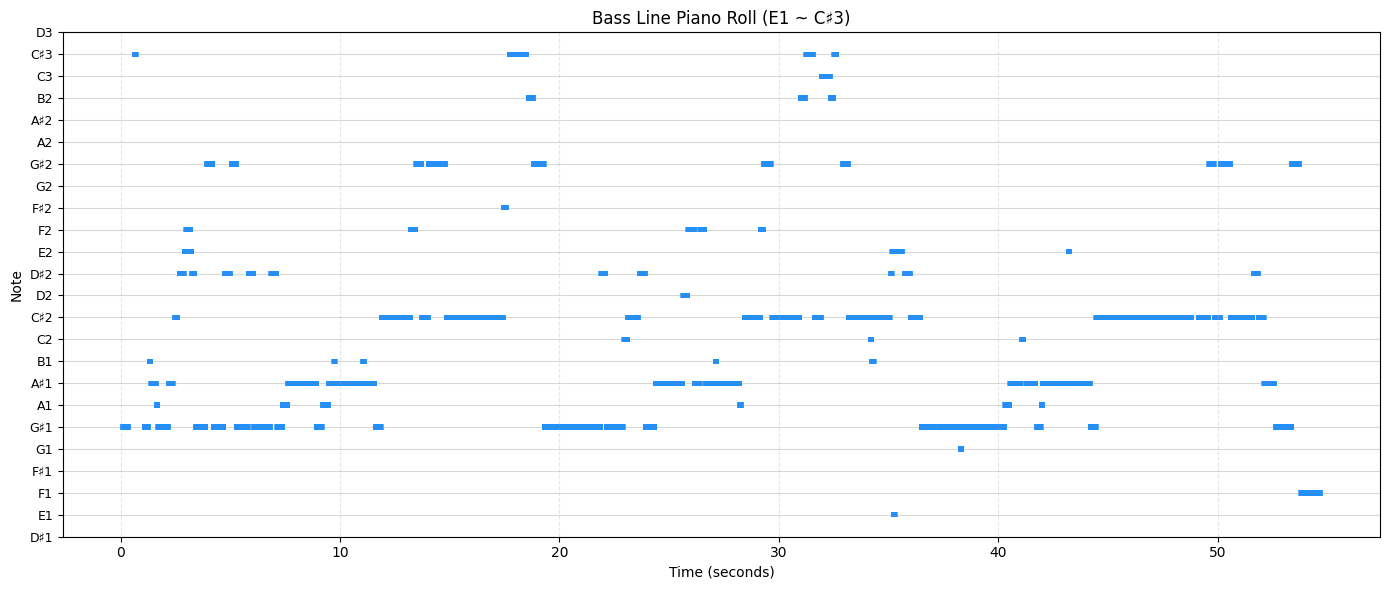

In [ ]:
def plot_optimized_piano_roll(f0_array, sr, hop_length):
    """
    [Visualization] 데이터가 존재하는 음역대만 딱 맞춰서 보여주는 피아노 롤
    """
    # 1. 데이터 유효성 검사
    valid_mask = ~np.isnan(f0_array) & (f0_array > 0)
    if np.sum(valid_mask) == 0:
        print("⚠️ 표시할 유효한 데이터가 없습니다.")
        return

    # 2. Hz -> MIDI 변환
    midi_notes = np.zeros_like(f0_array)
    midi_notes[valid_mask] = librosa.hz_to_midi(f0_array[valid_mask])

    # 3. 시간축 생성
    times = librosa.frames_to_time(np.arange(len(f0_array)), sr=sr, hop_length=hop_length)

    # 4. 그래프 그리기
    plt.figure(figsize=(14, 6))

    # 산점도 그리기 (marker='s'는 네모 모양, 피아노 롤 느낌)
    plt.scatter(times[valid_mask], midi_notes[valid_mask],
                c='dodgerblue', s=15, alpha=0.7, marker='s', edgecolors='none')

    # 5. Y축 범위 및 라벨 설정 (핵심 기능!)
    # 데이터에서 가장 낮은 음과 높은 음을 찾습니다.
    min_note_val = int(np.floor(np.min(midi_notes[valid_mask])))
    max_note_val = int(np.ceil(np.max(midi_notes[valid_mask])))

    # 위아래로 1반음(Semitone)씩 여유를 둡니다.
    plot_min = min_note_val - 1
    plot_max = max_note_val + 1

    # Y축 눈금(Ticks) 생성: 범위 내의 모든 정수(반음) 표시
    yticks = np.arange(plot_min, plot_max + 1)

    # 라벨 생성 (예: E1, F1, F#1 ...)
    yticklabels = [librosa.midi_to_note(n) for n in yticks]

    # 그래프 설정 적용
    plt.ylim(plot_min, plot_max)      # Y축 범위 고정
    plt.yticks(yticks, yticklabels, fontsize=9) # 글자 크기 조절

    # 격자(Grid)를 그려서 음 높이 보기가 편하게 함
    plt.grid(axis='y', linestyle='-', alpha=0.3, color='gray')
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    plt.title(f"Bass Line Piano Roll ({librosa.midi_to_note(min_note_val)} ~ {librosa.midi_to_note(max_note_val)})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Note")
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행
# ==========================================
plot_optimized_piano_roll(f0_final, sr=16000, hop_length=160)

In [ ]:
!pip install pretty_midi

In [ ]:
import pretty_midi
import numpy as np
import librosa

def save_to_midi(f0_array, sr, hop_length, output_path, velocity=100):
    """
    [Export] 분석된 f0 데이터를 MIDI 파일로 변환하여 저장
    - 연속된 같은 음은 하나의 긴 노트(Note On/Off)로 합칩니다.
    """
    # 1. PrettyMIDI 객체 생성
    pm = pretty_midi.PrettyMIDI()

    # 2. 악기 생성 (Electric Bass Finger = Program 33)
    # MIDI Program 번호는 0부터 시작하므로 33은 34번 악기(Electric Bass Pick) 또는 33(Finger)
    bass_program = pretty_midi.instrument_name_to_program('Electric Bass (finger)')
    bass_inst = pretty_midi.Instrument(program=bass_program)

    # 3. 시간 단위 계산 (1 프레임당 시간)
    frame_time = hop_length / sr

    # 4. 노트 변환 로직 (Grouping)
    current_note = None
    start_time = 0.0

    # f0 배열 순회
    for i, hz in enumerate(f0_array):
        # 현재 시간
        time = i * frame_time

        # 유효한 음인지 확인 (NaN이 아니고 0보다 커야 함)
        is_valid = (not np.isnan(hz)) and (hz > 0)

        # Hz -> MIDI Note Number 변환
        midi_note = int(round(librosa.hz_to_midi(hz))) if is_valid else None

        # --- 상태 머신 (State Machine) 로직 ---

        # Case A: 이전에 노트가 있었는데, 지금 끊겼거나 음이 바뀐 경우 -> 저장
        if current_note is not None:
            if (not is_valid) or (midi_note != current_note):
                # 노트 종료 및 추가
                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=current_note,
                    start=start_time,
                    end=time
                )
                bass_inst.notes.append(note)
                current_note = None # 초기화

        # Case B: 새로운 노트 시작 (이전에 노트가 없었거나, 음이 바뀐 경우)
        if is_valid:
            if current_note is None:
                current_note = midi_note
                start_time = time

    # 마지막에 노트가 열려있으면 닫아줌
    if current_note is not None:
         note = pretty_midi.Note(
            velocity=velocity,
            pitch=current_note,
            start=start_time,
            end=len(f0_array) * frame_time
        )
         bass_inst.notes.append(note)

    # 5. 악기 트랙 추가 및 파일 저장
    pm.instruments.append(bass_inst)
    pm.write(output_path)
    print(f"💾 MIDI Saved: {output_path}")

# ==========================================
# 실행
# ==========================================
# f0_final (이미 200Hz 컷오프 & 양자화 된 데이터) 사용
output_midi_path = "bass_transcription.mid"
save_to_midi(f0_final, sr=16000, hop_length=160, output_path=output_midi_path)

💾 MIDI Saved: bass_transcription.mid
